In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from typing import Callable, Optional, Tuple
from tqdm.notebook import tqdm

from IPython.display import clear_output

from torchvision.datasets.mnist import MNIST
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

# MNIST calculator

In this tutorial you are to implement a model that calculates the mod 10 sum of two digits in MNIST.

### Task 1. Prepare the data for the training.

Implement the `Digits` dataset class that wraps the MNIST class and augments it with the mod 10 sum of two digits.

In [2]:
class Digits(Dataset):
    def __init__(self, root: str, train: bool = True, download: bool = True, transforms: Optional[Callable] = None):
        super(Digits, self).__init__()

        # Construct your MNIST instance here
        self.mnist = MNIST(root=root, train=train, download=download, transform=transforms)

    def __getitem__(self, idx: int) -> Tuple[torch.FloatTensor, torch.FloatTensor, int]:
        """
        Returns the datapoint at index = idx.
        You need to implement this method in such a way
        that the ith element of the Digits class
        is a pair of subsequent MNIST dataset samples.
        That is if MNIST is [a, b, c, d], then Digits
        are [[a, b], [c, d]] and the label is mod 10
        sum of the MNIST labels.

        :param idx: Index of the datapoint.
        :return: 2 image tensors, their mod 10 sum.
        """

        ##### Write your code here #####

        ################################

    def __len__(self) -> int:
        """
        Returns the length of the dataset. Equals half the length of the MNIST dataset.

        :return: The total number of datapoints in the dataset.
        """

        ##### Write your code here #####

        ################################

Construct the train and the test splits of the dataset. Leave 90% of the training set for training and the remaining 10% for the validation.

In [ ]:
##### Write your code here #####


################################

### Task 2. Inspect data

Visualize some datapoints.

In [4]:
##### Write your code here #####

first, second, label = train_set[0]

################################

In [5]:
first.shape

torch.Size([1, 28, 28])

In [6]:
first.max()

tensor(1.)

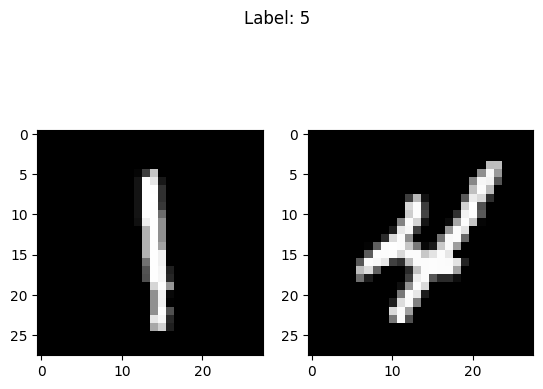

In [7]:
first, second, label = train_set[4]

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(first[0], cmap="gray")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(second[0], cmap="gray")

plt.suptitle(f"Label: {label}")

plt.show()

### Task 3. Train an MLP (multi-layer perceptron).

Design and train an MLP. Consider using different
activation functions, normalization layers and dropout. Plot all the training curves.

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        pass



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pass

In [8]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for first, second, labels in tqdm(train_dataloader):


        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


def evaluate(model, dataloader, loss_fn):




    return mean_loss, accuracy


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(n_epochs):



        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    return train_losses, val_losses, train_accuracies, val_accuracies


def plot(n_epochs, train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure()
    plt.plot(np.arange(n_epochs), train_losses)
    plt.plot(np.arange(n_epochs), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('Train/val loss')

    plt.figure()
    plt.plot(np.arange(n_epochs), train_accuracies)
    plt.plot(np.arange(n_epochs), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Train/val accuracy')





In [9]:
#make train, validation and test dataloaders

In [ ]:
#train the model

In [ ]:
plot(num_epochs, train_losses, val_losses, train_accuracies, val_accuracies)

Evaluate your model.

In [ ]:
#using testset, evaluate the model